# Matplotlib Style Recommendations


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mvdlib.plots
from mvdlib.style import (
    BASE,
    DIV,
    H1,
    H2,
    INK,
    LINES,
    SEQ,
)

plt.style.use("mvdlib.style.default")
FIGSIZE = mvdlib.plots.FigSize()

## Figure size and axis labels

**Recommendation:** Prefer single column figures. Adhere to journal size recommendations.

**Recommendation:** Use math mode for axes labels.

**Recommendation:** Use division to eliminate units. Use negative exponents to denote units in the denominator.


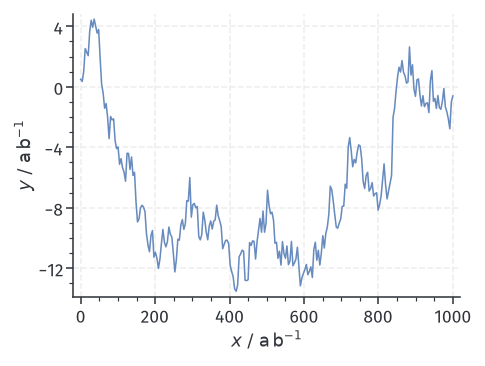

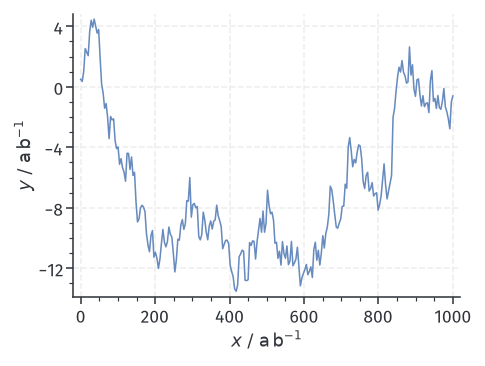

In [3]:
np.random.seed(42)
x = np.linspace(0.0, 1000, 250)
y = np.cumsum(np.random.randn(x.size))

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())

ax.plot(x, y, color=BASE)
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Colors

**Recommendation:** Keep colors to a minimum of 3.


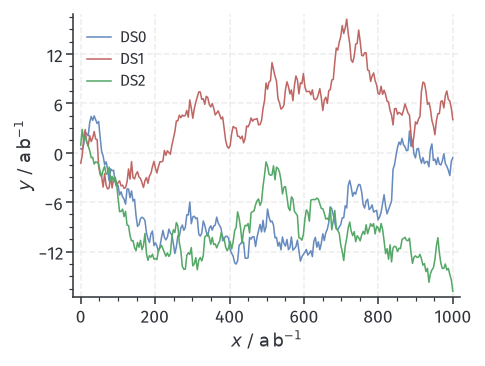

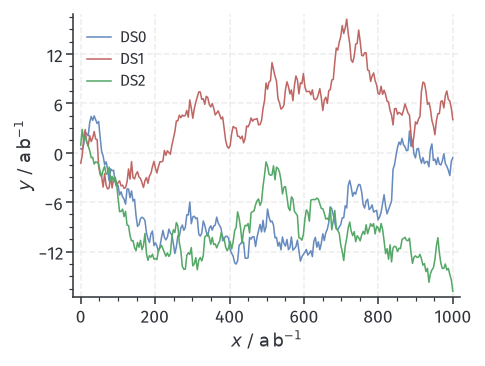

In [5]:
np.random.seed(42)
n = 3
x = np.linspace(0.0, 1000, 250)
y = [np.cumsum(np.random.randn(x.size)) for _ in range(n)]

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
for i in range(n):
    ax.plot(x, y[i], color=LINES[i], label=f"DS{i}")

ax.legend()
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Highlights and Transparency

**Recommendation:** De-emphasize individual traces with a thin, transparent base color; reserve a highlight for the aggregate and ink for the reference.


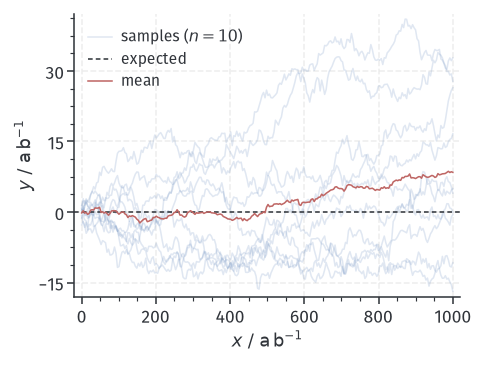

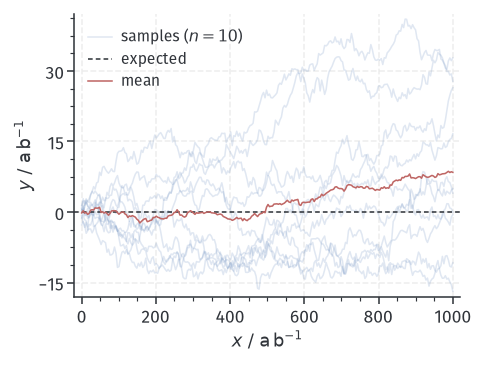

In [7]:
np.random.seed(42)
n = 10
x = np.linspace(0.0, 1000, 250)
y = [np.cumsum(np.random.randn(x.size)) for _ in range(n)]

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
for i, sample in enumerate(y):
    ax.plot(
        x, sample, color=BASE, alpha=0.2, zorder=1,
        label=f"samples ($n={n}$)" if i == 0 else "_nolegend_",
    )

ax.axhline(0.0, color=INK, ls=(0, (3, 2)), zorder=2, label="expected")
ax.plot(x, np.mean(y, axis=0), color=H1, zorder=3, label="mean")

ax.legend(loc="upper left")
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Sequential color maps

**Recommendation:** Use sequential colormaps to discriminate data that is connected by some hidden variable, like time.


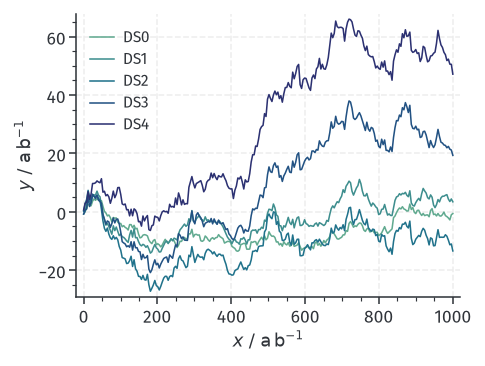

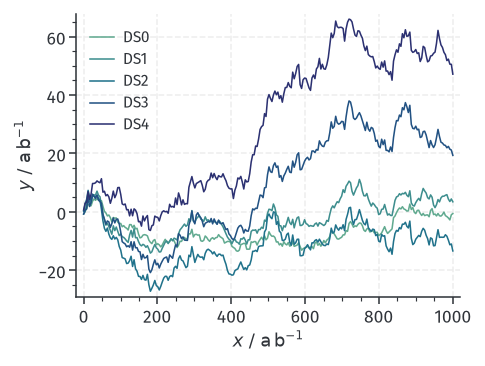

In [9]:
np.random.seed(42)

n = 5
x = np.linspace(0.0, 1000, 250)
ys = [np.cumsum(np.random.randn(x.size)) for _ in range(n)]
ys = np.cumsum(ys, axis=0)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
colors = SEQ(np.linspace(0.25, 1.0, n))
for i in range(n):
    ax.plot(x, ys[i], color=colors[i], label=f"DS{i}")

ax.legend(ncol=1)
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Column layouts

**Recommendation:** Use columns for shared y-axes. Use axes titles for designating panels. Adhere to journal size recommendations.


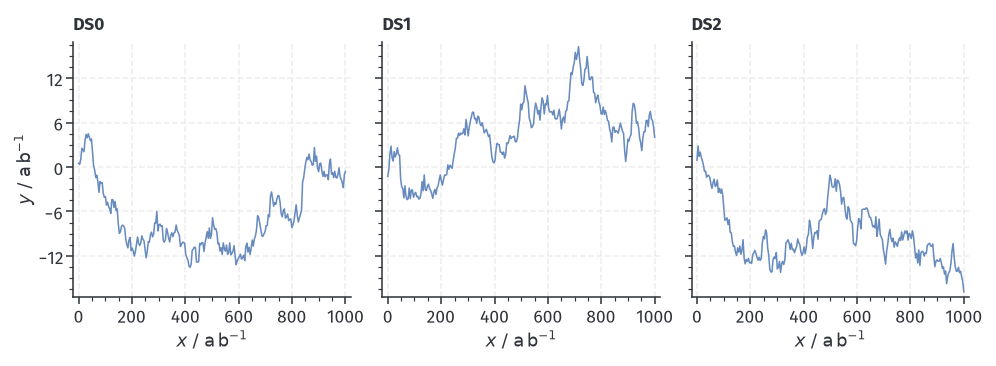

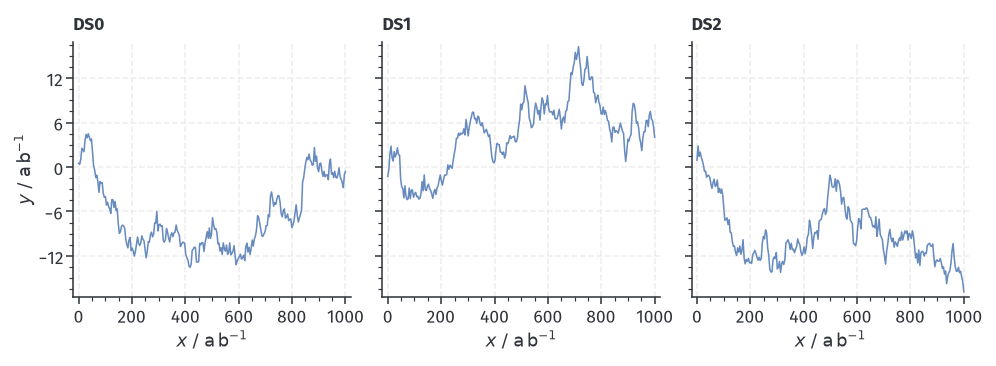

In [11]:
np.random.seed(42)

ncols = 3
x = np.linspace(0.0, 1000, 250)
y = [np.cumsum(np.random.randn(x.size)) for _ in range(ncols)]

fig, axes = plt.subplots(
    1, ncols, figsize=FIGSIZE(2), sharex=True, sharey=True
)
for i in range(ncols):
    axes[i].plot(x, y[i], color=BASE)
    axes[i].set_title(f"DS{i}")
    axes[i].set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")

axes[0].set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
axes[0].xaxis.set_major_locator(plt.MaxNLocator(6))
axes[0].yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Row layouts

**Recommendation:** Use rows for shared x-axes.


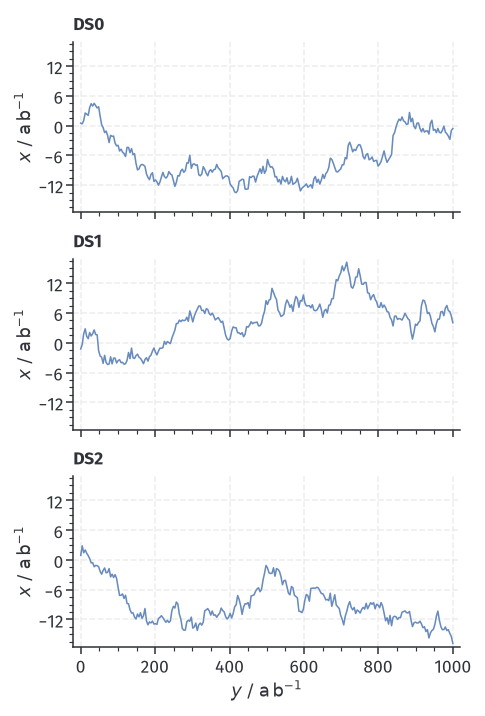

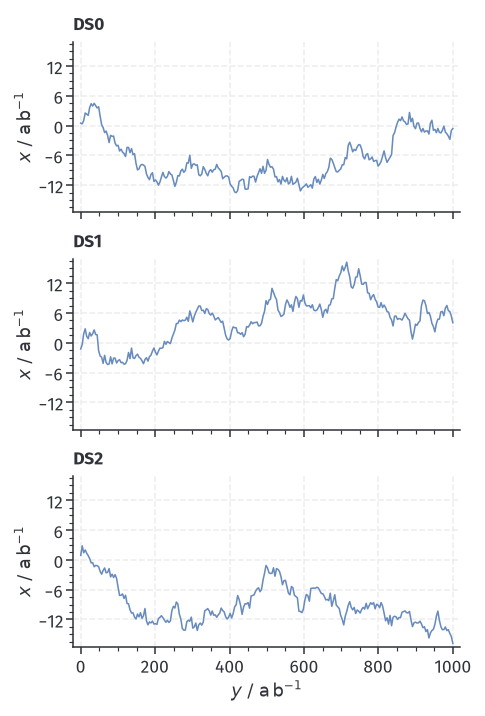

In [13]:
np.random.seed(42)

nrows = 3
x = np.linspace(0.0, 1000, 250)
y = [np.cumsum(np.random.randn(x.size)) for _ in range(nrows)]

fig, axes = plt.subplots(
    nrows, 1, figsize=FIGSIZE(1, 5.0), sharex=True, sharey=True
)
for i in range(nrows):
    axes[i].plot(x, y[i], color=BASE)
    axes[i].set_title(f"DS{i}")
    axes[i].set_ylabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")

axes[-1].set_xlabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
axes[-1].xaxis.set_major_locator(plt.MaxNLocator(6))
axes[-1].yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Meshes and contours

**Recommendation:** Use color meshes and contours to represent a third dimension.

**Recommendation:** Set equal aspect ratios for x- and y-axes with the same magnitude.


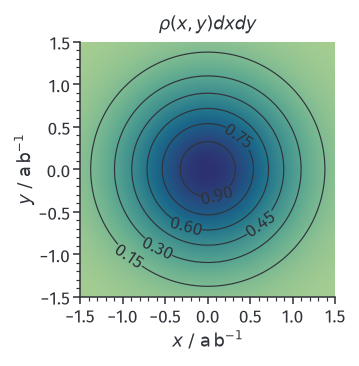

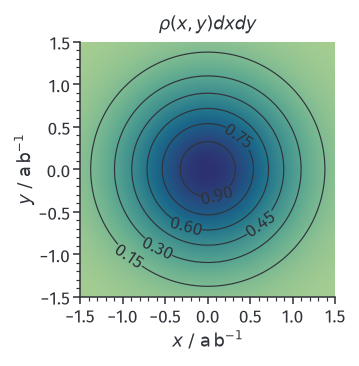

In [15]:
x = np.linspace(-1.5, 1.5, 250)
y = np.linspace(-1.5, 1.5, 250)
x, y = np.meshgrid(x, y)
z = np.exp(-(x ** 2) - y ** 2)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
mesh, contourset = mvdlib.plots.contourplot(ax, x, y, z, cmap=SEQ)

ax.set_aspect("equal")
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.set_title(r"$\rho(x, y)dxdy$", loc="center")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Diverging color maps

**Recommendation:** Use diverging color maps when displaying diverging data.


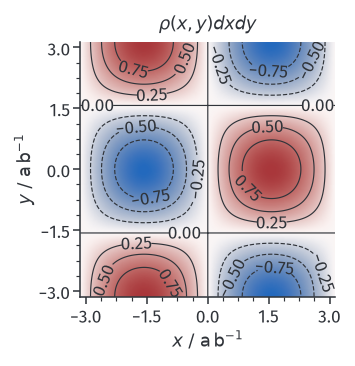

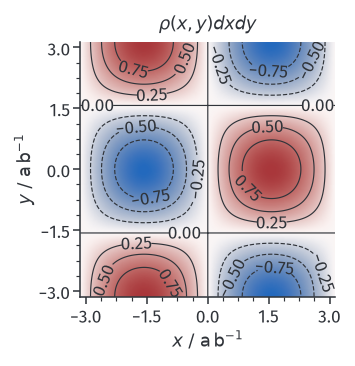

In [17]:
x = np.linspace(-np.pi, np.pi, 250)
y = x
x, y = np.meshgrid(x, y)
z = np.sin(x) * np.cos(y)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
mvdlib.plots.contourplot(ax, x, y, z, cmap=DIV)

ax.set_aspect("equal")
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.set_title(r"$\rho(x, y)dxdy$", loc="center")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Bar plots

**Recommendation:** Add values when showing bar plots.


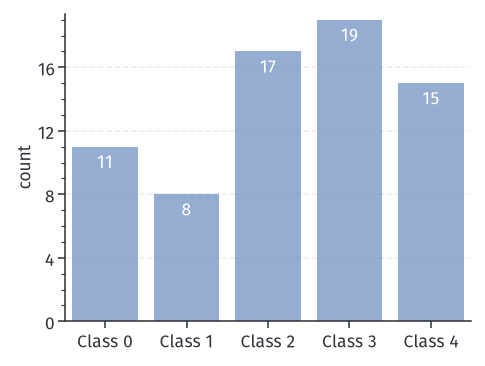

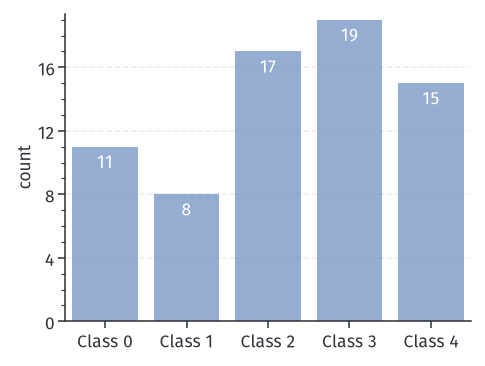

In [19]:
np.random.seed(42)
n = 5
classes = [f"Class {i}" for i in range(n)]
values = np.random.randint(5, 20, n)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.bar(classes, values, color=BASE, alpha=0.7)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(axis="x")
ax.set_ylabel("count")

for i in range(n):
    ax.text(
        i,
        values[i] - 0.3,
        f"{values[i]}",
        ha="center",
        va="top",
        color="white",
    )

plt.show()

## Kernel density estimation

**Recommendation:** Use kernel density estimation to show the distribution of data.


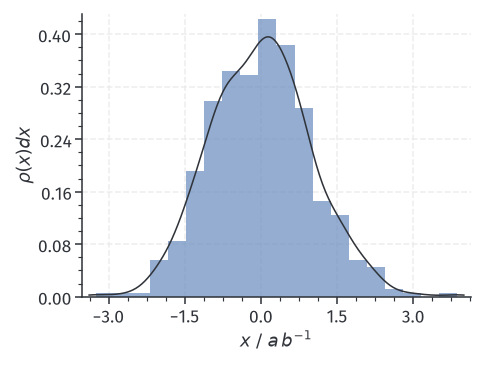

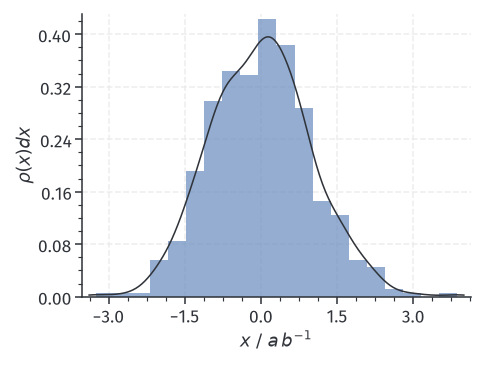

In [21]:
np.random.seed(42)
n = 500
x = np.random.randn(n)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.hist(x, density=True, color=BASE, alpha=0.7)
mvdlib.plots.kdeplot(ax, x, color=INK)

ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.set_xlabel(r"$x\ /\ a\,b^{-1}$")
ax.set_ylabel(r"$\rho(x)dx$")

plt.show()